# Get Information about BPMAI dataset from model files


Get creation date and print earlist and latest date


In [ ]:
import os
import json
import datetime

def get_bpmai_date_range():

    dataset_path = 'data/bpmnmodelset/bpmai/models'
    meta_file_ending = '.meta.json'

    files = os.listdir(dataset_path)

    earliest_model_date = datetime.datetime.max
    latest_model_date = datetime.datetime.min

    for file in files:
        if not file.endswith(meta_file_ending):
            continue

        meta_data_file = json.load(open(os.path.join(dataset_path, file), 'r'))

        model_date = datetime.datetime.fromisoformat(meta_data_file['model']['modelDate'])

        if model_date < earliest_model_date:
            earliest_model_date = model_date
        if model_date > latest_model_date:
            latest_model_date = model_date

    print("Earliest model date: ", earliest_model_date.isoformat())
    print("Last model date: ", latest_model_date.isoformat())

get_bpmai_date_range()

In [ ]:
def _extract_model_metadata(
        metadata_json) -> tuple[str, str, str]:
    id = metadata_json['model']['modelId']
    name = metadata_json['model']['modelName']
    language = metadata_json['model']['naturalLanguage']

    return id, name, language


def _load_model_text(fp: str) -> str:
    with open(fp, 'r') as f:
        model_text = f.read()
    return model_text


 Get language distribution


In [ ]:
from mcp4cm.bpmn.dataloading.dataloading import BPMNModelCollection
from mcp4cm.dataloading import load_dataset
from mcp4cm.base import DatasetType


bpmn_dataset = load_dataset(path='data/bpmnmodelset', dataset_type=DatasetType.BPMNMODELSET, bpmn_model_collection=BPMNModelCollection.BPMAI)




In [ ]:
from mcp4cm.language_detection import extract_dataset_languages, get_models_by_language
extract_dataset_languages(bpmn_dataset, override=False)
language_dict = get_models_by_language(bpmn_dataset, print_counts=True)



In [ ]:
len(language_dict.values())

In [ ]:
from mcp4cm.bpmn.data_extraction import extract_names_from_models, ELEMENT_COUNTS_COLUMN, _combine_name_and_count_dicts
from mcp4cm.bpmn.constants import NAMES_WITH_TYPES_COLUMN, NAMES_COLUMN, EMPTY_NAME_TOKEN, BASE_BPMN_DATASETS_PATH


extract_names_from_models(bpmn_dataset, use_types=True, include_texts=False, include_documentation=False)
extract_names_from_models(bpmn_dataset, use_types=False, include_texts=False, include_documentation=False)

In [ ]:
import json

from mcp4cm.util.text_util import join_texts

from collections import Counter

for model in bpmn_dataset:
    if "1230190255" in model.file_path:
        print("--- MODEL INFORMATION ---")
        print(model.name)
        print(model.file_path)
        print(model.names)
        print(model.names_with_types)
        print(model.element_counts)

        print("--- FOR HASHING ---")

        combined_dict = _combine_name_and_count_dicts(model.names_with_types, model.element_counts)
        print(json.dumps(model.names, sort_keys=True))
        print(json.dumps(combined_dict, sort_keys=True))

        print("--- FOR TF-IDF ---")
        names_joined = join_texts(model.names_with_types, delim=' ', empty_name=None)
        types_elements = list(Counter(model.element_counts).elements())
        types_joined = " ".join(types_elements)
        print(names_joined)
        print(types_joined)
        tf_idf_input = " ".join([names_joined, types_joined])
        print(tf_idf_input)

        break
    else:
        continue


# Analyzing texts

In [9]:
from mcp4cm.bpmn.dataloading.dataloading import load_processed_dataset_from_csv



sam_path = 'data/bpmnmodelset/processed/sap_sam_2022/names_only.csv'
bpmai_path = 'data/bpmnmodelset/processed/bpmai/names_only.csv'



In [10]:
english_bpmai = load_processed_dataset_from_csv('English_BPMAI', sam_path)

names
yes                                       240245
no                                        239508
acme ag                                   159266
supplier                                  100405
erp-system                                 98429
procurement                                64812
human resources department                 64003
central purchasing                         63845
head of human resources                    63818
receipt of goods                           63763
specify and quantify requirements          63755
work equipment                             63653
applicant                                  36319
reject                                     35139
accept                                     34279
5 days                                     33791
customer                                   33366
place order                                33082
send rejection                             33082
check stock                                32805
failed        

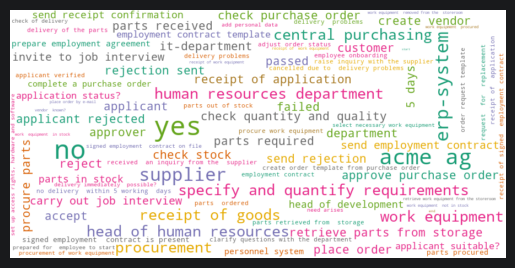

In [17]:
from mcp4cm.bpmn.analysis_and_extraction import get_counts, create_wordcloud

counts = get_counts(english_bpmai, key = 'names', casefold=True, exclude_empty=True)

create_wordcloud(counts)
counts.head(50)

In [12]:
counts_with_empty = get_counts(english_bpmai, key='names', casefold=True, exclude_empty=False)

total = sum(counts_with_empty)
unnamed = counts_with_empty['unnamed']
print("'unnamed' tokens after text extraction:", unnamed)
print("Total number of names (excluding 'unnamed') in dataset:", total - unnamed)

'unnamed' tokens after text extraction: 763892
Total number of names (excluding 'unnamed') in dataset: 13905226


In [13]:
from mcp4cm.bpmn.filter_functions import filter_models_by_median_name_length

filter_models_by_median_name_length(english_bpmai, inplace=True)

C:\Entwicklung\envs\py3_13_BA_EAKG\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Entwicklung\envs\py3_13_BA_EAKG\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Filtered out models with a median name length smaller than 3: 35779


Dataset(name=English_BPMAI, models=583028)

In [14]:
from mcp4cm.bpmn.language_detection import filter_models_by_language

english_bpmai = filter_models_by_language(english_bpmai, language='en', key='names', empty_name='unnamed')

names
yes                                       240245
no                                        239508
acme ag                                   159266
supplier                                  100405
erp-system                                 98429
procurement                                64812
human resources department                 64003
central purchasing                         63845
head of human resources                    63818
receipt of goods                           63763
specify and quantify requirements          63755
work equipment                             63653
applicant                                  36319
reject                                     35139
accept                                     34279
5 days                                     33791
customer                                   33366
place order                                33082
send rejection                             33082
check stock                                32805
failed        

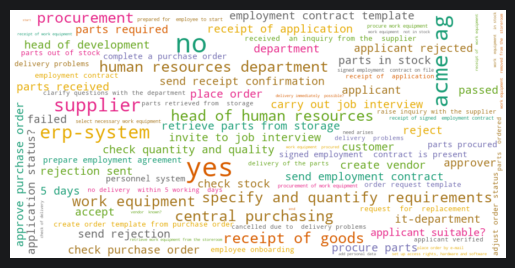

In [18]:
from mcp4cm.bpmn.analysis_and_extraction import get_counts, create_wordcloud

counts = get_counts(english_bpmai, key = 'names', casefold=True, exclude_empty=True)

create_wordcloud(counts)
counts.head(50)

In [19]:
counts.head(50)

names
yes                                       240245
no                                        239508
acme ag                                   159266
supplier                                  100405
erp-system                                 98429
procurement                                64812
human resources department                 64003
central purchasing                         63845
head of human resources                    63818
receipt of goods                           63763
specify and quantify requirements          63755
work equipment                             63653
applicant                                  36319
reject                                     35139
accept                                     34279
5 days                                     33791
customer                                   33366
place order                                33082
send rejection                             33082
check stock                                32805
failed        